In [2]:
!ls


best_model.pth		load_data.py	 run_main_jointActLoc.py  train.py
config_modifier.py	model		 run_main.py		  train_ssl.py
inference_only.py	preprocess.py	 run.sh			  utils.py
InspectingJEPA.ipynb	preset.py	 train_count.py
InspectingOutput.ipynb	run_dualband.py  train_joint.py


In [1]:

from logging import raiseExceptions

import numpy as np
from sklearn.model_selection import train_test_split
#
from model import *
from preset import preset
from load_data import load_data_x, load_data_y, encode_data_y
from utils import *
#
import os
import time
import torch
import numpy as np
from sklearn.model_selection import train_test_split
import torch.nn as nn
from torch.utils.data import TensorDataset
from ptflops import get_model_complexity_info
from itertools import permutations
from sklearn.metrics import classification_report, accuracy_score
from scipy.optimize import linear_sum_assignment
from train import train
from preset import preset
import torch.nn.functional as F
from utils import *
import wandb
from model.JEPA import *
from utils import *


ModuleNotFoundError: No module named 'numpy'

In [18]:
model_states["model_state_dict"].keys()

odict_keys(['online_cnn_feature_extractor.initial_conv.weight', 'online_cnn_feature_extractor.initial_conv.bias', 'online_cnn_feature_extractor.bn_initial.weight', 'online_cnn_feature_extractor.bn_initial.bias', 'online_cnn_feature_extractor.bn_initial.running_mean', 'online_cnn_feature_extractor.bn_initial.running_var', 'online_cnn_feature_extractor.bn_initial.num_batches_tracked', 'online_cnn_feature_extractor.ds_conv1.depthwise.weight', 'online_cnn_feature_extractor.ds_conv1.depthwise.bias', 'online_cnn_feature_extractor.ds_conv1.pointwise.weight', 'online_cnn_feature_extractor.ds_conv1.pointwise.bias', 'online_cnn_feature_extractor.bn_ds1.weight', 'online_cnn_feature_extractor.bn_ds1.bias', 'online_cnn_feature_extractor.bn_ds1.running_mean', 'online_cnn_feature_extractor.bn_ds1.running_var', 'online_cnn_feature_extractor.bn_ds1.num_batches_tracked', 'online_cnn_feature_extractor.hierarchical_dilated_1.conv.weight', 'online_cnn_feature_extractor.hierarchical_dilated_1.conv.bias', 'o


▶ Extracting representations from the model...
✓ Representations extracted. Shape: (1881, 48)

▶ Computing t-SNE visualization (perplexity=50)...


/home/amirmhd/anaconda3/envs/WiMANS/lib/python3.9/site-packages/sklearn/manifold/_t_sne.py:982: FutureWarning: The PCA initialization in TSNE will change to have the standard deviation of PC1 equal to 1e-4 in 1.2. This will ensure better convergence.
  warnings.warn(


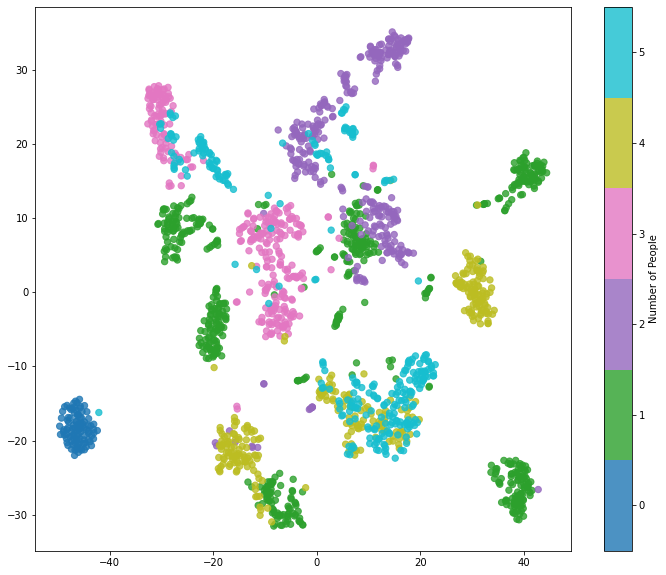

In [23]:
config["predictor_attention_heads"] = 2
config["encoder_attention_heads"] = 4

# Set the missing n_attention_heads parameter
config["n_attention_heads"] = config["encoder_attention_heads"]  # Use 4 for encoder

# Ensure cnn_output_channels is divisible by n_attention_heads
# Get the current value or set a compatible one
if "cnn_output_channels" not in config:
    config["cnn_output_channels"] = 512  # Default value divisible by 4
else:
    # Make sure it's divisible by the number of attention heads
    output_channels = config["cnn_output_channels"]
    n_heads = config["n_attention_heads"]
    if output_channels % n_heads != 0:
        # Round up to nearest multiple
        config["cnn_output_channels"] = ((output_channels + n_heads - 1) // n_heads) * n_heads
        print(f"Adjusted cnn_output_channels from {output_channels} to {config['cnn_output_channels']} to be divisible by {n_heads}")

model_path = load_path + checkpoint
model_states = torch.load(model_path, map_location=device)

# Initialize and load model
model = JEPA_Model(config=config).to(device)
model.load_state_dict(state_dict=model_states["model_state_dict"])
model.eval()



# 2. Extract representations
print("\n▶ Extracting representations from the model...")
dataset = TensorDataset(torch.from_numpy(data_x).float())
dataloader = torch.utils.data.DataLoader(dataset, batch_size=32, shuffle=False)

all_representations = []
with torch.no_grad():
    for batch in dataloader:
        data_batch_x = batch[0].to(device)
        representations = model.extract_representations(data_batch_x)
        all_representations.append(representations.cpu().numpy())

representations_np = np.concatenate(all_representations, axis=0)
print(f"✓ Representations extracted. Shape: {representations_np.shape}")

# 3. Compute t-SNE visualization
print("\n▶ Computing t-SNE visualization (perplexity=50)...")
tsne_model = TSNE(
    n_components=2, 
    perplexity=50,
    n_iter=1000, 
    random_state=42, 
    n_jobs=-1,
    init='pca', 
    learning_rate='auto'
)

tsne_results = tsne_model.fit_transform(representations_np)

plt.figure(figsize=(12, 10))

# Find unique labels to create distinct colors
unique_labels = np.unique(num_people)
num_unique_labels = len(unique_labels)

# Use a qualitative colormap suitable for categorical data
cmap = plt.get_cmap('tab10', num_unique_labels)

# Create the scatter plot
scatter = plt.scatter(
    tsne_results[:, 0],
    tsne_results[:, 1],
    c=num_people,
    cmap=cmap,
    alpha=0.8,
    s=40,
    # Set vmin and vmax to map colors correctly to integer labels
    vmin=unique_labels.min() - 0.5,
    vmax=unique_labels.max() + 0.5
)

# Create a colorbar with ticks corresponding to each unique label
cbar = plt.colorbar(scatter, ticks=unique_labels, label="Number of People")
cbar.ax.tick_params(labelsize=10)
    

In [ ]:
load_path  = "/home/amirmhd/Documents/multi_modal_CSI/benchmark/wifi_csi/model/saved_models/jepa_ssl_meeting_room+empty_room+classroom_20250611_201026/"
var_model = preset["model"]
var_repeat = preset["repeat"]
var_users = ["0","1", "2", "3", "4", "5"]
environments_to_load = ["meeting_room", "empty_room", "classroom"]

In [ ]:
load_path = "/home/amirmhd/Documents/multi_modal_CSI/benchmark/wifi_csi/model/saved_models/jepa_ssl_meeting_room+classroom_20250615_170721/"
json_file_path = load_path + "jepa_ssl_results.json"
# with open(json_file_path, 'r') as f:
#     data = json.load(f)
#     config = data.get("config")
#     environments_to_load = data["environments"]
environments_to_load = ["meeting_room"]  # ["empty_room", "meeting_room", "classroom"]
    # "meeting_room", "classroom"]
JEPA_CONFIG = preset["jepa"]
JEPA_CONFIG.update(preset["nn"])  # Merge with neural network hyperparameters
JEPA_CONFIG.update(preset["data"])  # Merge with data selection parameters
JEPA_CONFIG["num_target_blocks"] = int(JEPA_CONFIG["num_segments_total_view"] * 0.22)
JEPA_CONFIG["cnn_embedding_time_dim"] = int(JEPA_CONFIG["segment_length"] / 20) 
config = JEPA_CONFIG.copy()

# Define model checkpoints to analyze
model_checkpoints = [
    "best_model.pth",
    # "checkpoint_epoch_100.pth", 
    # "checkpoint_epoch_200.pth",
    # "checkpoint_epoch_300.pth",
    # "checkpoint_epoch_400.pth", 
    # "checkpoint_epoch_500.pth"
]


var_users = ["0","1", "2", "3", "4", "5"]



# ========== Load Data ==========
print(f"Loading data for environments: {environments_to_load}")
# Load labels to get the list of CSI files
data_pd_y = load_data_y(
    preset["path"]["data_y"],
    var_environment=environments_to_load,
    var_wifi_band=preset["data"]["wifi_band"],
    var_num_users=preset["data"]["num_users"]
)
var_label_list = data_pd_y["label"].to_list()

# Load CSI data (X) and labels (Y)
data_x = load_data_x(preset["path"]["data_x"], var_label_list)
print(f"CSI data loaded successfully. Shape: {data_x.shape}")

# Process labels
y = encode_data_y(data_pd_y, preset["task"])
data_y = np.array(y)  # Shape: (num_samples, 6, 9)
labels = data_y.sum(axis=1)  # Shape: (num_samples, 9)
num_people = labels.sum(axis=1)  # Calculate total number of people once
print(f"Labels processed. Total samples: {len(data_x)}")

# Reshape data to match model input
data_x = data_x.reshape(data_x.shape[0], data_x.shape[1], -1)

# Set device for model computation
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ========== Process Each Model Checkpoint ==========
print("\n" + "="*50)
print("Starting analysis of model checkpoints")
print("="*50)

for checkpoint in model_checkpoints:
    print(f"\n{'='*20} Analyzing {checkpoint} {'='*20}")
    
    # 1. Load model from checkpoint
    try:
        model_path = load_path + checkpoint
        model_states = torch.load(model_path, map_location=device)
        
        # Initialize and load model
        model = JEPA_Model(config=config).to(device)
        model.load_state_dict(state_dict=model_states["model_state_dict"])
        model.eval()
        print(f"✓ Model successfully loaded from: {checkpoint}")
    except Exception as e:
        print(f"✗ Error loading model from {checkpoint}: {str(e)}")
        continue
    
    # 2. Extract representations
    print("\n▶ Extracting representations from the model...")
    dataset = TensorDataset(torch.from_numpy(data_x).float())
    dataloader = torch.utils.data.DataLoader(dataset, batch_size=32, shuffle=False)
    
    all_representations = []
    with torch.no_grad():
        for batch in dataloader:
            data_batch_x = batch[0].to(device)
            representations = model.extract_representations(data_batch_x)
            all_representations.append(representations.cpu().numpy())
    
    representations_np = np.concatenate(all_representations, axis=0)
    print(f"✓ Representations extracted. Shape: {representations_np.shape}")
    
    # 3. Compute t-SNE visualization
    print("\n▶ Computing t-SNE visualization (perplexity=50)...")
    tsne_model = TSNE(
        n_components=2, 
        perplexity=50,
        n_iter=1000, 
        random_state=42, 
        n_jobs=-1,
        init='pca', 
        learning_rate='auto'
    )
    
    tsne_results = tsne_model.fit_transform(representations_np)
    
    plt.figure(figsize=(12, 10))

    # Find unique labels to create distinct colors
    unique_labels = np.unique(num_people)
    num_unique_labels = len(unique_labels)

    # Use a qualitative colormap suitable for categorical data
    cmap = plt.get_cmap('tab10', num_unique_labels)

    # Create the scatter plot
    scatter = plt.scatter(
        tsne_results[:, 0],
        tsne_results[:, 1],
        c=num_people,
        cmap=cmap,
        alpha=0.8,
        s=40,
        # Set vmin and vmax to map colors correctly to integer labels
        vmin=unique_labels.min() - 0.5,
        vmax=unique_labels.max() + 0.5
    )

    # Create a colorbar with ticks corresponding to each unique label
    cbar = plt.colorbar(scatter, ticks=unique_labels, label="Number of People")
    cbar.ax.tick_params(labelsize=10)
    
    # 4. Perform SVD analysis
    print("\n▶ Analyzing representation dimensionality with SVD...")
    U, s, Vh = np.linalg.svd(representations_np, full_matrices=False)
    
    # Plot singular values
    plt.figure(figsize=(10, 6))
    plt.plot(s[:50], marker='o', linestyle='-')
    plt.title(f'Top 50 Singular Values - {checkpoint}')
    plt.xlabel('Singular Value Index')
    plt.ylabel('Magnitude')
    plt.yscale('log')
    plt.grid(True)
    plt.show()
    
    # Plot cumulative explained variance
    explained_variance_ratio = (s**2) / np.sum(s**2)
    cumulative_explained_variance = np.cumsum(explained_variance_ratio)
    
    plt.figure(figsize=(10, 6))
    plt.plot(cumulative_explained_variance[:100], marker='.', linestyle='-')
    plt.title(f'Cumulative Explained Variance - {checkpoint}')
    plt.xlabel('Number of Components')
    plt.ylabel('Cumulative Explained Variance')
    plt.grid(True)
    plt.axhline(y=0.95, color='r', linestyle='--', label='95% Variance')
    plt.axhline(y=0.99, color='g', linestyle='--', label='99% Variance')
    plt.legend()
    plt.show()
    
    # Calculate key metrics
    num_components_95 = np.argmax(cumulative_explained_variance >= 0.95) + 1
    num_components_99 = np.argmax(cumulative_explained_variance >= 0.99) + 1
    
    print(f"\n📊 SVD Analysis Results for {checkpoint}:")
    print(f"  • Representation dimensionality: {representations_np.shape[1]}")
    print(f"  • Components needed for 95% variance: {num_components_95}")
    print(f"  • Components needed for 99% variance: {num_components_99}")
    print(f"  • Intrinsic dimensionality ratio: {num_components_95/representations_np.shape[1]:.2f}")

print("\n" + "="*50)
print("Analysis of all model checkpoints complete!")
print("="*50)

Loading data for environments: ['meeting_room']
CSI data loaded successfully. Shape: (1881, 3000, 3, 3, 30)
Labels processed. Total samples: 1881
Using device: cuda

Starting analysis of model checkpoints

==================== Analyzing best_model.pth ====================
✗ Error loading model from best_model.pth: embed_dim must be divisible by num_heads

Analysis of all model checkpoints complete!


<AxesSubplot:xlabel='tsne1', ylabel='tsne2'>

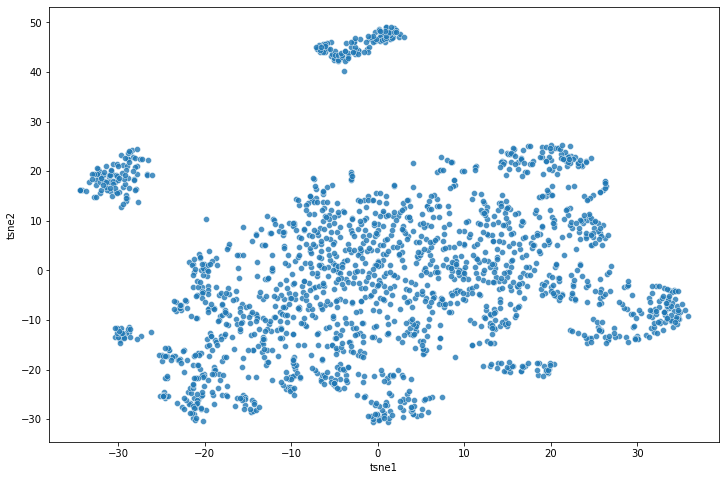

Loading model from: /home/amirmhd/Documents/multi_modal_CSI/benchmark/wifi_csi/model/saved_models/jepa_ssl_meeting_room+empty_room+classroom_20250611_201026/


In [17]:
model_states

{'epoch': 100,
 'model_state_dict': OrderedDict([('online_cnn_feature_extractor.initial_conv.weight',
               tensor([[[ 0.0568],
                        [-0.0617],
                        [-0.0228],
                        ...,
                        [ 0.0547],
                        [-0.0164],
                        [-0.0042]],
               
                       [[ 0.0485],
                        [-0.0501],
                        [ 0.0289],
                        ...,
                        [ 0.0638],
                        [ 0.0368],
                        [-0.0331]],
               
                       [[ 0.0630],
                        [ 0.0214],
                        [-0.0468],
                        ...,
                        [-0.0077],
                        [ 0.0597],
                        [-0.0528]],
               
                       ...,
               
                       [[-0.0406],
                        [ 0.0095],
                

In [19]:
model = JEPA_Model(config=config).to(device)
model.load_state_dict(state_dict=model_states["model_state_dict"])
model.eval()
print("Model loaded successfully.")

# model.load_state_dict(state_dict)
# model.eval()

Model loaded successfully.


In [13]:
# 2. ========== Load Data ==========
print(f"Loading data for environments: {environments_to_load}")
# Load labels to get the list of CSI files
data_pd_y = load_data_y(
    preset["path"]["data_y"],
    var_environment=environments_to_load,
    var_wifi_band=preset["data"]["wifi_band"],
    var_num_users=preset["data"]["num_users"]
)
var_label_list = data_pd_y["label"].to_list()

# Load CSI data (X) and labels (Y)
data_x = load_data_x(preset["path"]["data_x"], var_label_list)


#
## load CSI amplitude

y = encode_data_y(data_pd_y, preset["task"])
data_y = np.array(y) # Shape: (num_samples, 6, 9)

# Process labels as described: sum over the 'users' axis
labels = data_y.sum(axis=1) # Shape: (num_samples, 9)
print(f"Loaded {len(data_x)} samples.")

# Reshape data to match model input
data_x = data_x.reshape(data_x.shape[0], data_x.shape[1], -1)


Loading data for environments: ['meeting_room', 'empty_room', 'classroom']
Loaded 5643 samples.


In [20]:
# 3. ========== Extract Representations ==========
print("Extracting representations from the model...")
dataset = TensorDataset(torch.from_numpy(data_x).float())
dataloader = DataLoader(dataset, batch_size=32, shuffle=False)

all_representations = []
for batch in dataloader:
    data_batch_x = batch[0].to(device)
    with torch.no_grad():
        representations = model.extract_representations(data_batch_x)
    all_representations.append(representations.cpu().numpy())
    
representations_np = np.concatenate(all_representations, axis=0)
print(f"Representations extracted. Shape: {representations_np.shape}")


Extracting representations from the model...
Representations extracted. Shape: (5643, 64)


Starting t-SNE computations for different perplexities...

Computing t-SNE with perplexity=50... (this may take a few minutes)


/home/amirmhd/anaconda3/envs/WiMANS/lib/python3.9/site-packages/sklearn/manifold/_t_sne.py:982: FutureWarning: The PCA initialization in TSNE will change to have the standard deviation of PC1 equal to 1e-4 in 1.2. This will ensure better convergence.
  warnings.warn(


t-SNE computation complete for perplexity=50.

--- Generating Plot A: By Total Number of People (Perplexity=50) ---


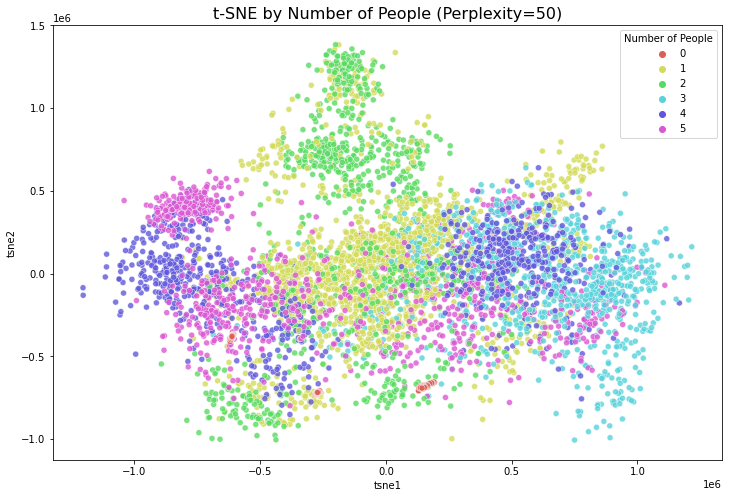


All t-SNE computations and Plot A generations complete.


In [21]:

from sklearn.manifold import TSNE
data_x_n = data_x.sum(axis=1)
# Define the list of perplexity values to iterate over
perplexity_values = [50]  # 5 different perplexities

# Calculate num_people once, as it's independent of perplexity
# Ensure 'labels' variable is available from previous cells
num_people = labels.sum(axis=1)

print("Starting t-SNE computations for different perplexities...")

# Loop through each perplexity value
for perplexity_val in perplexity_values:
    # 4. ========== Compute t-SNE for current perplexity ==========
    print(f"\nComputing t-SNE with perplexity={perplexity_val}... (this may take a few minutes)")

    # Initialize TSNE with the current perplexity
    # Using init='pca' and learning_rate='auto' for potentially better/more stable results
    tsne_model = TSNE(n_components=2, perplexity=perplexity_val,
                      n_iter=1000, random_state=42, n_jobs=-1,
                      init='pca', learning_rate='auto')

    # Fit and transform the representations
    # Ensure 'representations_np' variable is available from previous cells
    tsne_results = tsne_model.fit_transform(data_x_n)
    print(f"t-SNE computation complete for perplexity={perplexity_val}.")

    # 5. ========== Generate Plot A for current perplexity ==========
    # Plot A: Visualize by Total Number of People
    print(f"\n--- Generating Plot A: By Total Number of People (Perplexity={perplexity_val}) ---")

    # Ensure 'create_tsne_plot' function is available (e.g., from utils)
    create_tsne_plot(
        tsne_results,
        num_people,
        title=f"t-SNE by Number of People (Perplexity={perplexity_val})",
        legend_title="Number of People"
    )

print("\nAll t-SNE computations and Plot A generations complete.")
# Note: The 'tsne_results' variable now holds the results for the last perplexity value processed.
# Subsequent cells (e.g., for Plot B and Plot C) will use these 'tsne_results'.

In [ ]:

from sklearn.manifold import TSNE
data_x_n = data_x.reshape(data_x.shape[0], -1)
# Define the list of perplexity values to iterate over
perplexity_values = [50]  # 5 different perplexities

# Calculate num_people once, as it's independent of perplexity
# Ensure 'labels' variable is available from previous cells
num_people = labels.sum(axis=1)

print("Starting t-SNE computations for different perplexities...")

# Loop through each perplexity value
for perplexity_val in perplexity_values:
    # 4. ========== Compute t-SNE for current perplexity ==========
    print(f"\nComputing t-SNE with perplexity={perplexity_val}... (this may take a few minutes)")

    # Initialize TSNE with the current perplexity
    # Using init='pca' and learning_rate='auto' for potentially better/more stable results
    tsne_model = TSNE(n_components=2, perplexity=perplexity_val,
                      n_iter=500, random_state=42, n_jobs=-1,
                      init='pca', learning_rate='auto')

    # Fit and transform the representations
    # Ensure 'representations_np' variable is available from previous cells
    tsne_results = tsne_model.fit_transform(data_x_n)
    print(f"t-SNE computation complete for perplexity={perplexity_val}.")

    # 5. ========== Generate Plot A for current perplexity ==========
    # Plot A: Visualize by Total Number of People
    print(f"\n--- Generating Plot A: By Total Number of People (Perplexity={perplexity_val}) ---")

    # Ensure 'create_tsne_plot' function is available (e.g., from utils)
    create_tsne_plot(
        tsne_results,
        num_people,
        title=f"t-SNE by Number of People (Perplexity={perplexity_val})",
        legend_title="Number of People"
    )

print("\nAll t-SNE computations and Plot A generations complete.")
# Note: The 'tsne_results' variable now holds the results for the last perplexity value processed.
# Subsequent cells (e.g., for Plot B and Plot C) will use these 'tsne_results'.

Starting t-SNE computations for different perplexities...

Computing t-SNE with perplexity=5... (this may take a few minutes)


Starting t-SNE computations for different perplexities...

Computing t-SNE with perplexity=5... (this may take a few minutes)


/home/amirmhd/anaconda3/envs/WiMANS/lib/python3.9/site-packages/sklearn/manifold/_t_sne.py:982: FutureWarning: The PCA initialization in TSNE will change to have the standard deviation of PC1 equal to 1e-4 in 1.2. This will ensure better convergence.
  warnings.warn(


t-SNE computation complete for perplexity=5.

--- Generating Plot A: By Total Number of People (Perplexity=5) ---


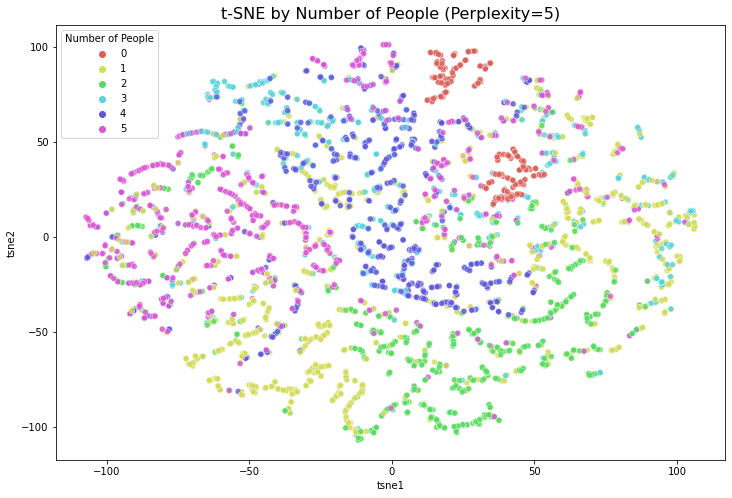


Computing t-SNE with perplexity=10... (this may take a few minutes)


/home/amirmhd/anaconda3/envs/WiMANS/lib/python3.9/site-packages/sklearn/manifold/_t_sne.py:982: FutureWarning: The PCA initialization in TSNE will change to have the standard deviation of PC1 equal to 1e-4 in 1.2. This will ensure better convergence.
  warnings.warn(


t-SNE computation complete for perplexity=10.

--- Generating Plot A: By Total Number of People (Perplexity=10) ---


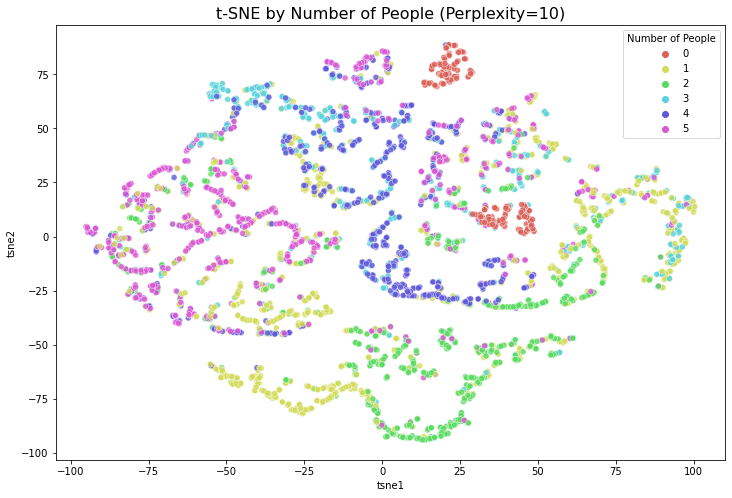


Computing t-SNE with perplexity=20... (this may take a few minutes)


/home/amirmhd/anaconda3/envs/WiMANS/lib/python3.9/site-packages/sklearn/manifold/_t_sne.py:982: FutureWarning: The PCA initialization in TSNE will change to have the standard deviation of PC1 equal to 1e-4 in 1.2. This will ensure better convergence.
  warnings.warn(


t-SNE computation complete for perplexity=20.

--- Generating Plot A: By Total Number of People (Perplexity=20) ---


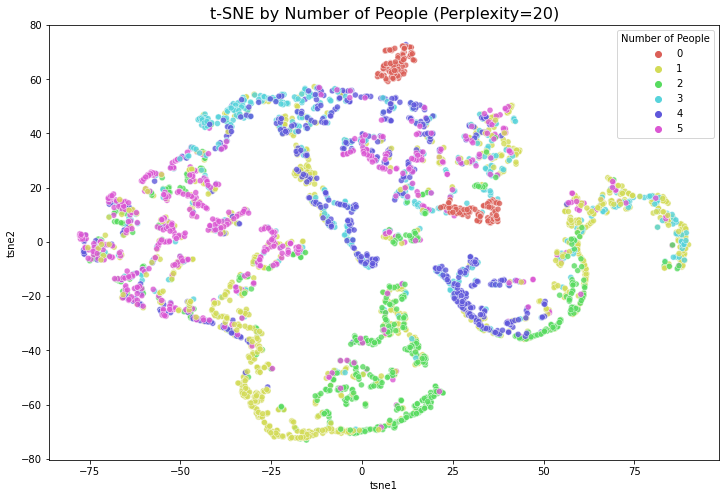


Computing t-SNE with perplexity=30... (this may take a few minutes)


/home/amirmhd/anaconda3/envs/WiMANS/lib/python3.9/site-packages/sklearn/manifold/_t_sne.py:982: FutureWarning: The PCA initialization in TSNE will change to have the standard deviation of PC1 equal to 1e-4 in 1.2. This will ensure better convergence.
  warnings.warn(


t-SNE computation complete for perplexity=30.

--- Generating Plot A: By Total Number of People (Perplexity=30) ---


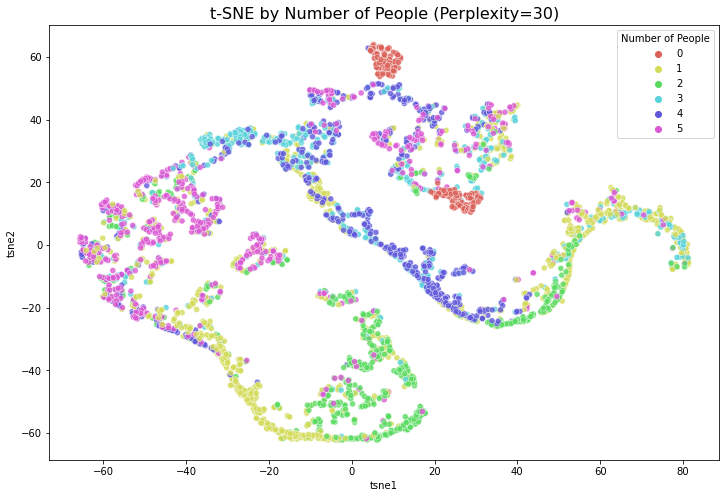


Computing t-SNE with perplexity=40... (this may take a few minutes)


/home/amirmhd/anaconda3/envs/WiMANS/lib/python3.9/site-packages/sklearn/manifold/_t_sne.py:982: FutureWarning: The PCA initialization in TSNE will change to have the standard deviation of PC1 equal to 1e-4 in 1.2. This will ensure better convergence.
  warnings.warn(


t-SNE computation complete for perplexity=40.

--- Generating Plot A: By Total Number of People (Perplexity=40) ---


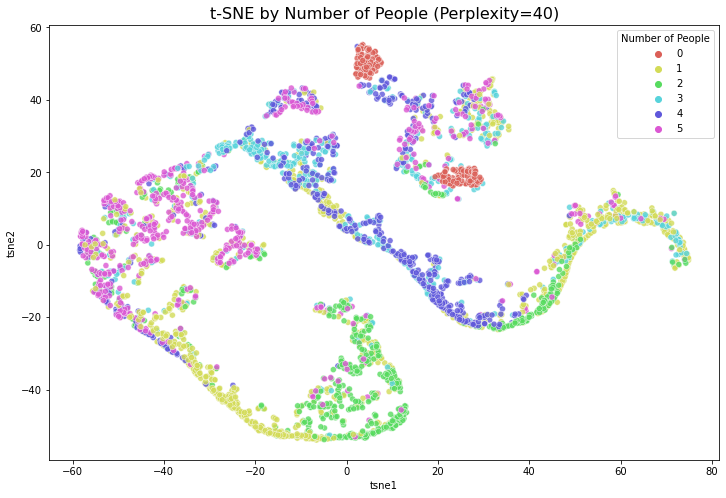


Computing t-SNE with perplexity=50... (this may take a few minutes)


/home/amirmhd/anaconda3/envs/WiMANS/lib/python3.9/site-packages/sklearn/manifold/_t_sne.py:982: FutureWarning: The PCA initialization in TSNE will change to have the standard deviation of PC1 equal to 1e-4 in 1.2. This will ensure better convergence.
  warnings.warn(


t-SNE computation complete for perplexity=50.

--- Generating Plot A: By Total Number of People (Perplexity=50) ---


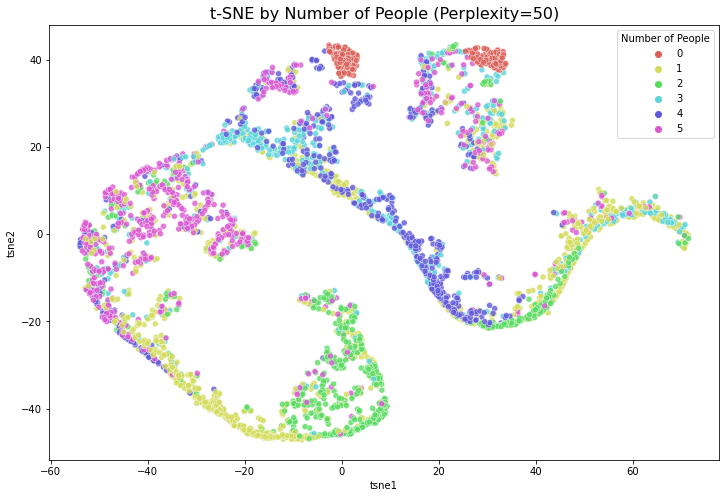


Computing t-SNE with perplexity=60... (this may take a few minutes)


/home/amirmhd/anaconda3/envs/WiMANS/lib/python3.9/site-packages/sklearn/manifold/_t_sne.py:982: FutureWarning: The PCA initialization in TSNE will change to have the standard deviation of PC1 equal to 1e-4 in 1.2. This will ensure better convergence.
  warnings.warn(


t-SNE computation complete for perplexity=60.

--- Generating Plot A: By Total Number of People (Perplexity=60) ---


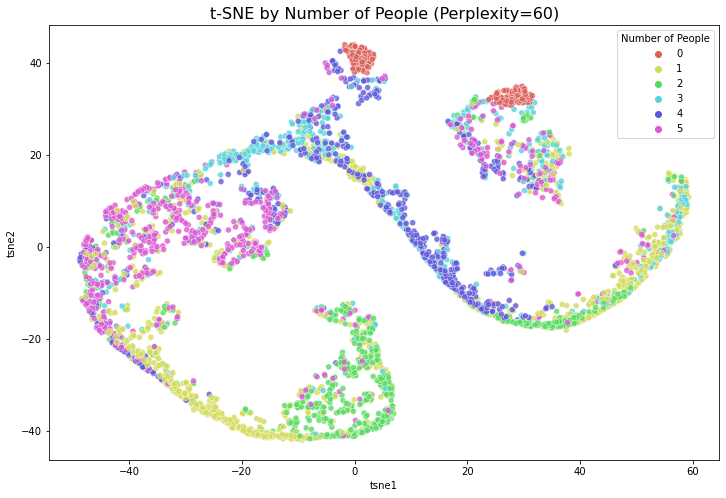


Computing t-SNE with perplexity=80... (this may take a few minutes)


/home/amirmhd/anaconda3/envs/WiMANS/lib/python3.9/site-packages/sklearn/manifold/_t_sne.py:982: FutureWarning: The PCA initialization in TSNE will change to have the standard deviation of PC1 equal to 1e-4 in 1.2. This will ensure better convergence.
  warnings.warn(


t-SNE computation complete for perplexity=80.

--- Generating Plot A: By Total Number of People (Perplexity=80) ---


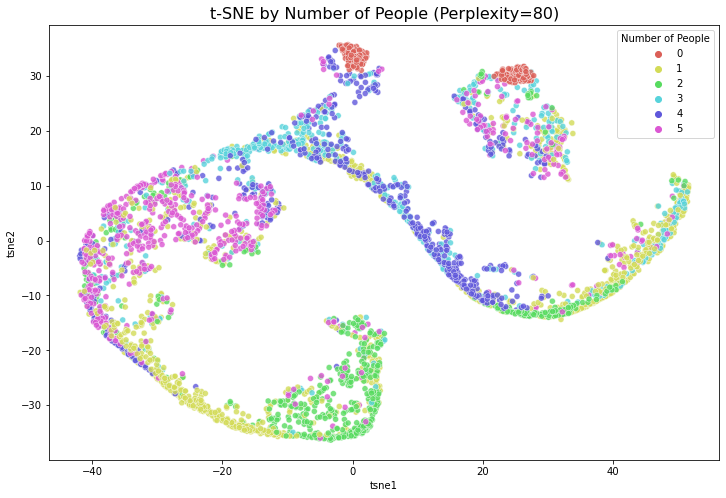


Computing t-SNE with perplexity=100... (this may take a few minutes)


/home/amirmhd/anaconda3/envs/WiMANS/lib/python3.9/site-packages/sklearn/manifold/_t_sne.py:982: FutureWarning: The PCA initialization in TSNE will change to have the standard deviation of PC1 equal to 1e-4 in 1.2. This will ensure better convergence.
  warnings.warn(


t-SNE computation complete for perplexity=100.

--- Generating Plot A: By Total Number of People (Perplexity=100) ---


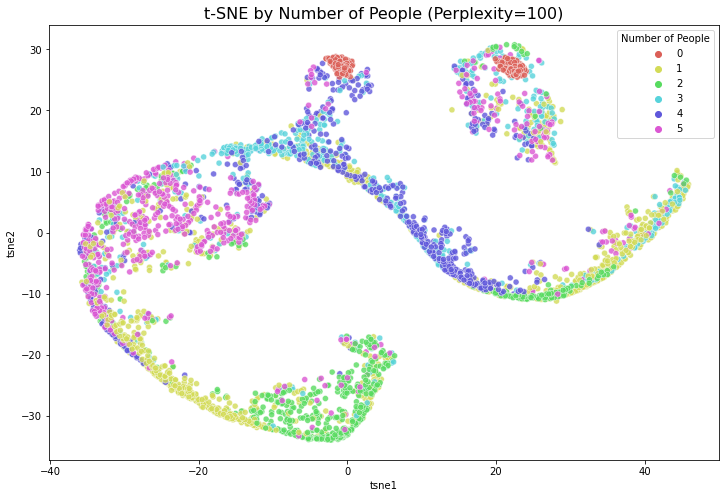


All t-SNE computations and Plot A generations complete.


In [48]:
from sklearn.manifold import TSNE


# Define the list of perplexity values to iterate over
perplexity_values = [5, 10, 20, 30, 40, 50, 60, 80, 100]  # 5 different perplexities

# Calculate num_people once, as it's independent of perplexity
# Ensure 'labels' variable is available from previous cells
num_people = labels.sum(axis=1)

print("Starting t-SNE computations for different perplexities...")

# Loop through each perplexity value
for perplexity_val in perplexity_values:
    # 4. ========== Compute t-SNE for current perplexity ==========
    print(f"\nComputing t-SNE with perplexity={perplexity_val}... (this may take a few minutes)")
    
    # Initialize TSNE with the current perplexity
    # Using init='pca' and learning_rate='auto' for potentially better/more stable results
    tsne_model = TSNE(n_components=2, perplexity=perplexity_val, 
                      n_iter=1000, random_state=42, n_jobs=-1, 
                      init='pca', learning_rate='auto')
    
    # Fit and transform the representations
    # Ensure 'representations_np' variable is available from previous cells
    tsne_results = tsne_model.fit_transform(representations_np)
    print(f"t-SNE computation complete for perplexity={perplexity_val}.")

    # 5. ========== Generate Plot A for current perplexity ==========
    # Plot A: Visualize by Total Number of People
    print(f"\n--- Generating Plot A: By Total Number of People (Perplexity={perplexity_val}) ---")
    
    # Ensure 'create_tsne_plot' function is available (e.g., from utils)
    create_tsne_plot(
        tsne_results,
        num_people,
        title=f"t-SNE by Number of People (Perplexity={perplexity_val})",
        legend_title="Number of People"
    )

print("\nAll t-SNE computations and Plot A generations complete.")
# Note: The 'tsne_results' variable now holds the results for the last perplexity value processed.
# Subsequent cells (e.g., for Plot B and Plot C) will use these 'tsne_results'.

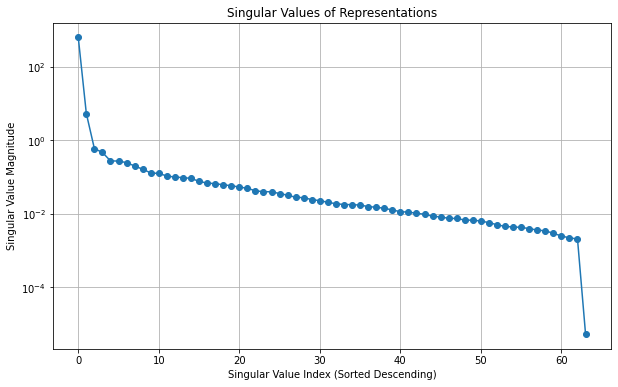

Shape of U: (5643, 64)
Shape of s (singular values): (64,)
Shape of Vh: (64, 64)

First 10 singular values: [6.2703790e+02 5.3433757e+00 5.9417570e-01 4.6609288e-01 2.7467686e-01
 2.7132192e-01 2.4626765e-01 1.9946262e-01 1.6292815e-01 1.2910017e-01]
Last 10 singular values: [4.3784184e-03 4.2528883e-03 3.9503733e-03 3.5882278e-03 3.4350278e-03
 2.9386068e-03 2.4839828e-03 2.2028843e-03 2.0634814e-03 5.3489166e-06]


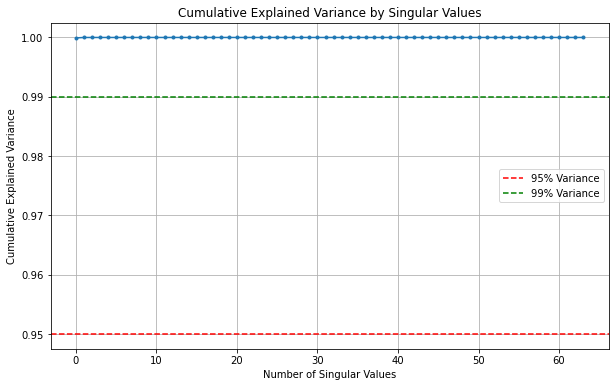

Number of components to explain 95% variance: 1
Number of components to explain 99% variance: 1


In [22]:
representations_np.shape
import matplotlib.pyplot as plt

# Perform SVD
U, s, Vh = np.linalg.svd(representations_np, full_matrices=False)

# Plot the singular values
plt.figure(figsize=(10, 6))
plt.plot(s, marker='o', linestyle='-')
plt.title('Singular Values of Representations')
plt.xlabel('Singular Value Index (Sorted Descending)')
plt.ylabel('Singular Value Magnitude')
plt.yscale('log') # Use log scale to better visualize smaller values
plt.grid(True)
plt.show()

print(f"Shape of U: {U.shape}")
print(f"Shape of s (singular values): {s.shape}")
print(f"Shape of Vh: {Vh.shape}")
print("\nFirst 10 singular values:", s[:10])
print("Last 10 singular values:", s[-10:])

# You can also look at the cumulative explained variance
explained_variance_ratio = (s**2) / np.sum(s**2)
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

plt.figure(figsize=(10, 6))
plt.plot(cumulative_explained_variance, marker='.', linestyle='-')
plt.title('Cumulative Explained Variance by Singular Values')
plt.xlabel('Number of Singular Values')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Variance')
plt.axhline(y=0.99, color='g', linestyle='--', label='99% Variance')
plt.legend()
plt.show()

num_components_95 = np.argmax(cumulative_explained_variance >= 0.95) + 1
num_components_99 = np.argmax(cumulative_explained_variance >= 0.99) + 1
print(f"Number of components to explain 95% variance: {num_components_95}")
print(f"Number of components to explain 99% variance: {num_components_99}")

In [37]:
import os
import torch

# Directory containing the models
load_path = "/home/amirmhd/Documents/multi_modal_CSI/benchmark/wifi_csi/model/saved_models/jepa_ssl/"

# Get all model files (excluding json files)
model_files = [f for f in os.listdir(load_path) if f.endswith('.pth') and not f.startswith('jepa_ssl_results')]
print(f"Found {len(model_files)} model files:")
for model in model_files:
    print(f"  - {model}")

# Initialize dictionary to store model names and their ema_decay values
model_ema_values = {}

# Load each model and extract the ema_decay value
for model_name in model_files:
    try:
        state_dict = torch.load(load_path + model_name, map_location=device)
        ema_decay = state_dict["config"]["ema_decay"]
        model_ema_values[model_name] = ema_decay
    except Exception as e:
        print(f"Error loading model {model_name}: {str(e)}")

# Sort models by ema_decay value (from highest to lowest)
sorted_models = sorted(model_ema_values.items(), key=lambda x: x[1], reverse=True)

# Find the highest ema_decay value
if sorted_models:
    max_ema = sorted_models[0][1]
    
    # Print models with the highest ema_decay
    print("\nModels with highest ema_decay value:")
    for model_name, ema_decay in sorted_models:
        if ema_decay >= max_ema:
            print(f"Model: {model_name}, ema_decay: {ema_decay}")
else:
    print("No models were successfully loaded.")

Found 6 model files:
  - jepa_ssl_meeting_room+empty_room_20250610_205216.pth
  - jepa_ssl_meeting_room+empty_room_20250610_190953.pth
  - jepa_ssl_meeting_room+empty_room_20250610_164213.pth
  - jepa_ssl_meeting_room+empty_room_20250611_030028.pth
  - jepa_ssl_meeting_room+empty_room_20250610_232710.pth
  - jepa_ssl_meeting_room+empty_room_20250609_184929.pth

Models with highest ema_decay value:
Model: jepa_ssl_meeting_room+empty_room_20250610_190953.pth, ema_decay: 0.998
Model: jepa_ssl_meeting_room+empty_room_20250610_164213.pth, ema_decay: 0.998


In [ ]:
load_path = "/home/amirmhd/Documents/multi_modal_CSI/benchmark/wifi_csi/model/saved_models/jepa_ssl/"
model_name = "jepa_ssl_meeting_room+empty_room_20250610_232710.pth"


In [34]:
state_dict = torch.load(load_path + model_name, map_location=device)
print("state dict config", state_dict["config"]["ema_decay"])

state dict config 0.994


In [ ]:
model = JEPA_Model(state_dict["config"]).to(device)
model.load_state_dict(state_dict["model_state_dict"])
model.eval()
print("Model loaded successfully.")

# model.load_state_dict(state_dict)
# model.eval()

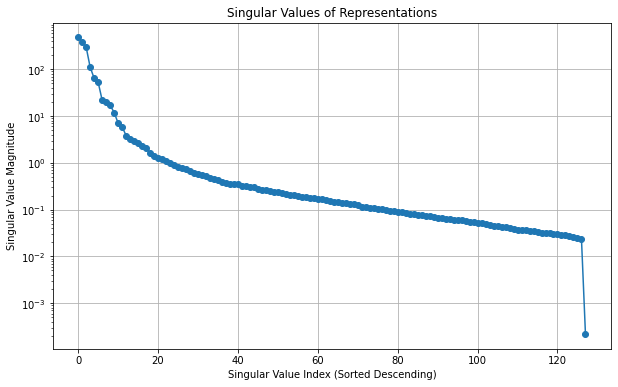

Shape of U: (3762, 128)
Shape of s (singular values): (128,)
Shape of Vh: (128, 128)

First 10 singular values: [480.78235  388.90625  298.05566  111.18309   64.51027   53.043106
  21.983725  19.689093  17.204966  11.938117]
Last 10 singular values: [0.03125291 0.03042588 0.03008006 0.02897883 0.02809021 0.02705866
 0.02635502 0.02528939 0.02386448 0.00021921]


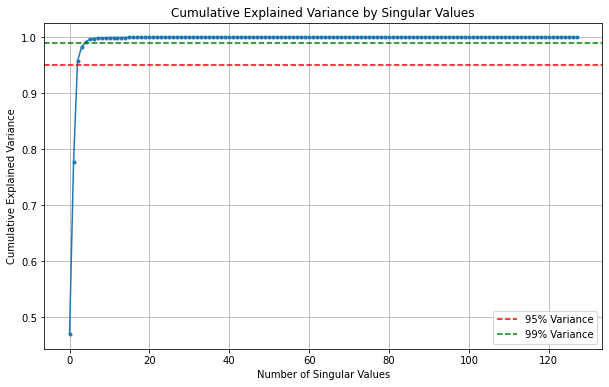

Number of components to explain 95% variance: 3
Number of components to explain 99% variance: 5


In [ ]:
representations_np.shape
import matplotlib.pyplot as plt

# Perform SVD
U, s, Vh = np.linalg.svd(representations_np, full_matrices=False)

# Plot the singular values
plt.figure(figsize=(10, 6))
plt.plot(s, marker='o', linestyle='-')
plt.title('Singular Values of Representations')
plt.xlabel('Singular Value Index (Sorted Descending)')
plt.ylabel('Singular Value Magnitude')
plt.yscale('log') # Use log scale to better visualize smaller values
plt.grid(True)
plt.show()

print(f"Shape of U: {U.shape}")
print(f"Shape of s (singular values): {s.shape}")
print(f"Shape of Vh: {Vh.shape}")
print("\nFirst 10 singular values:", s[:10])
print("Last 10 singular values:", s[-10:])

# You can also look at the cumulative explained variance
explained_variance_ratio = (s**2) / np.sum(s**2)
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

plt.figure(figsize=(10, 6))
plt.plot(cumulative_explained_variance, marker='.', linestyle='-')
plt.title('Cumulative Explained Variance by Singular Values')
plt.xlabel('Number of Singular Values')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Variance')
plt.axhline(y=0.99, color='g', linestyle='--', label='99% Variance')
plt.legend()
plt.show()

num_components_95 = np.argmax(cumulative_explained_variance >= 0.95) + 1
num_components_99 = np.argmax(cumulative_explained_variance >= 0.99) + 1
print(f"Number of components to explain 95% variance: {num_components_95}")
print(f"Number of components to explain 99% variance: {num_components_99}")

In [ ]:
import matplotlib.pyplot as plt

# Perform SVD
U, s, Vh = np.linalg.svd(data_x.reshape(data_x.shape[0]* data_x.shape[1], -1), full_matrices=False)

# Plot the singular values
plt.figure(figsize=(10, 6))
plt.plot(s, marker='o', linestyle='-')
plt.title('Singular Values of Representations')
plt.xlabel('Singular Value Index (Sorted Descending)')
plt.ylabel('Singular Value Magnitude')
plt.yscale('log') # Use log scale to better visualize smaller values
plt.grid(True)
plt.show()

print(f"Shape of U: {U.shape}")
print(f"Shape of s (singular values): {s.shape}")
print(f"Shape of Vh: {Vh.shape}")
print("\nFirst 10 singular values:", s[:10])
print("Last 10 singular values:", s[-10:])

# You can also look at the cumulative explained variance
explained_variance_ratio = (s**2) / np.sum(s**2)
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

plt.figure(figsize=(10, 6))
plt.plot(cumulative_explained_variance, marker='.', linestyle='-')
plt.title('Cumulative Explained Variance by Singular Values')
plt.xlabel('Number of Singular Values')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Variance')
plt.axhline(y=0.99, color='g', linestyle='--', label='99% Variance')
plt.legend()
plt.show()

num_components_95 = np.argmax(cumulative_explained_variance >= 0.95) + 1
num_components_99 = np.argmax(cumulative_explained_variance >= 0.99) + 1
print(f"Number of components to explain 95% variance: {num_components_95}")
print(f"Number of components to explain 99% variance: {num_components_99}")